WGAN (WASSERSTEING GAN): RISOLVERE L'INSTABILITA' GENERATIVA.

Le GAN sono macchine meravogliose, ma un piccolo errore nei parametri e tutto crolla.
E' come cercare di costruire un castello di carta durante un terremoto.
La WGAN è una riformulazione matematica del duello avversario.
Riscriveremo la funzione di distanza tra la reatà e il sogno della macchina e come questo risolve il problema dell'instabilità

Una GAN classica chiede al Discriminatore: "questa immagine è vera o false?"
Una WGAN chiede al Critic: "quanto questa immagine appartiene più alla distribuzione reale che a quella generata?"

Con questa piccola modifica, cambia la qualità del segnale che arriva al Generatore. LA WGAN è stata introdotta da Arjovsky, Chintale e Bottou per ottenere training più stabile e curve loss più informative.

Con la GAN o la DBGAN si calcola la divergenza tra la distribuzione reale e quella generata.
Se due distribuzioni sono completamente separate la misura può dire sostanzialmente "sono completamente diverse" 
Lo stesso risultavo potrei averlo sia per distribuzioni tanto diverse che per distribuzioni tanto tanto diverse.
Se le due distribuzioni non si sovrappongono perfettamente, la divergenza della GAN diventa costante. Questo causa il fenomeno della scomparsa dei gradienti, rendendo impossibile l'addestramento. 
Quindi non è sempre un'inidcazione utile che dice in quale direzione avvicinarle.
Per il Generator questo può essere un problema

La WGAN usa la Wasserstein-1 distance che può essere tradotta come:
la quantità minima di lavoro necessaria per trasformare una distribuzione nell'altra

Esempio:
per farla semplice immaginiamo un numero
REAL=10  FAKE=100
la distanza iniziale è 90, dopo un pò la distinza è 50 poi 40, 20, 1 ed infine 0
Quindi puoi vedere chiaramente 90-50-40-20-1-0
Questo è esattamente il tipo di informazione che vogliamo ottenere drante il training.

questa distanza della WGAN si chiama Earth Mover's Distance (EMD)
Immagina di avere un cumulo di terra (la distribuzione generata) e di volerlo spostare per riempire una buca della stessa forma (distribuzione reale), la distaza misura il lavoro necessario cos' la massa moltiplicata per lo spostamento.
La EMD ci dice quanto due distirbuzioni sono lontane
- La distanza di Wasserstein misura il lavoro minimo necessario per trasformare una distribuzione di probabilità in un'altra
- A differenza della distanza delle GAN (JS), la EMD è continua e differenziabile quasi ovunque, fornendo gradienti utili anche quando le distribuzioni sono lontane.
- L'analogia classica è quella di due cumuli di terra: la distanza è il prodotto della massa per lo spostamento.
- Questa metrica permette al generatore di ricevere un segnale informativo costante, indipendentemente dalla qualità iniziale dei campioni.

La divergenza JS 'ignora' quanto siano distanti due distribuzioni, restituendo sempre lo stesso valore massimo (o sei vicino o sei fuori, se se fuori il segnale è nullo). Wasserstein decresce linearmente man mano che il generatore si avvicina ai dati reali (il valore decresce), guidando la rete con precisione.
WGAN è robusta anche quando il generatore produce immagini inizialmente molto diverse dal target (rumore casuale), evitando il blocco del training.

Qui cambia la Terminologia - Da Discriminator a Critic
Non è solo un cambio di nome, nella GAN il Discriminator produce probabilità 0...1. Il Critic produce score reale, esempio 8.7 3.2 -1.4 -12.6 e non sono probabilità
score più alto -> immagini reali
score più basso -> immagini fake

Di conseguienza sparisce la Sigmoide.
Nella GAN avevamo nn.Conv2d(...) - nn.Sigmoid()
con la WGAN abbiamo nn.Conv2d(...)
perchè vogliamo un numero non limitato

Sparisce anche BCELoss
nella GAN abbiamo criterion=nn.BCELoss()
perchè stavamo facendo classificazoine binaria real=1 fake=0
Nella WGAN non stiamo più facendo classificazione, quindi niente BCELoss
La loss deriva direttamente dagli score del Critic.
loss_crictic= (torch.mean(cristic_fake)-torch.mean(critic_real))
Il Critic vuole minimizzare quindi tenderà a rendere
real ancora più alto
fake ancora più basso
esempio
real=12 fake=0 loss=(fake-real)=(0-12)=-12

Mentre il Generator vuole che il Critic assegni alla fake uno score alto
loss_gen= - torch.mean(critic(fake))
Esempio:
critic(fake)=-10  lossG=-(-10) = 10
critic(fake)=+5   lossG=-(-5) = -5
G preferusce -5 rispetto a +10
Quindi tenederà a produrre immagini alle quali C attribuisce score sempre più elevato

La pendenza della funzione però non deve superare un certo valore, come mettere un limitatore di velocità per assicurarci che il gradiente non esploda.

Nella WGAN il suo compito non è più fare il poliziotto che mette vero o falso. Diventa un critico (Critic) che assegna un punteggio di realismo continuo.
Rimuovere la funzione Sigmoide finale, permette al cristico di restituire valore arbitrari che rappresentano la qualità dei campioni senza saturazione.
Non interessa dare una probabilità, interessa misurare la distanza semantica.
Questo elimina la saturazione e permette al dialogo tra le dure reti di rimanere sempre vivo e di portare informazione reale.

Ma come garantiamo che i gradienti non esplodono 
La funzione ha una pendenza limitata: questo garantisce che i gradienti non esplodano durante l'ottimizzazione.
La tecnica originale prevede di forzare i pesi del Critico in un intervallo piccolo (es. -0.01, +0.01)
Sebbene brutale, il clipping dei pesi è sufficiente per garantire che il Critico rimanga all'interno dello spazio delle funzioni ammissibili

In questa stabilità possiamo addestrare meglio il nostro insegnante.
Nelle GAN classiche infatti temiamo che Discriminatore troppo forte uccide il Generatore.
Nelle WGAN abbiamo un Critico ottimale, da addestrare molto più di un Generatore, solitamente gli facciamo fare 5 passi di addestramento per ogni singolo aggiornamento del Generatore
n(critic)=5
In questo modo, quando tocca il Generatore generare, riceve già un consiglio da parte di un critico istruito.
Questo assicura che il Generatore riceva sempre un gradiente che riflette la vera geometrica delle distanza di Wasserstein.

Vantaggio e Diagnostica
Uno dei problemi storici delle GAN è l'impossibilità di capire se il modello sta migliorando guardando solo i grafici delle loss. La loss oscillava senza capire se il modello stesse imparando
La WGAN introduce una proprietà rivoluzionaria: la loss del Critico è direttamente proporzionale alla qualità visiva dei campioni generati. Se il numero scende l'immagine migliora. Non è più necessario il controllo visivo ad ogni batch per capire se sta migliorando.

Correlazione della Loss
Monitoraggio affidabile del training.
- Man mano che la distanza di Wasserstein diminuisce, i campioni generati passano dal rumore o forme coerenti.
- Inolre la WGAN è quasi immunte al 'Mode Collapse' poichè il gradiente non svanisce mai, forzando il generatore a coprire l'intera variatà dei dati.
- La stabilità è tale da permettere l'addestramento di architetture profonde senza la necessità di un tunning maniacale degli iperparametri.

Robustezza Architetturale
A differenza delle DCGAN, le WGAN originale sono meno dipendenti dalla Batch Normalization per mantenere la stabilità (mancanza di Batch Norm)
Si preferisce l'ottimizzazione RMSprop ad Adam perchè non utilizza il momentum che può interferire negativamente con il clipping dei pesi (ottimizzatore RMSprop). Adam entra in conflitto creando instabilità.
L'uso di una loss lineare rimuove i problemi di instabilità numerica tipici delle funzioni logaritmiche nella fasi critiche.

Interpretare il Punteggio del Critico
La WGAN, grazie alla sua visione gemoetrica il punteggio del critico diventa una guida sicura per rifinire i dettagli, senza perdere la distirbuzione globale. Il calcolo della loss dice quanto siamo 'vicini' alla varietà dei dati reali.
Questa proprietà rende la WGAN lo strumento ideale per dataset complessi e rumorosi come SVHN, dove il realismo è difficile da quantificare.

Inizio addestramento WGAN su SVHN...
Epoch [0/20] Batch 0/1145 	W-Dist: 0.0040
Epoch [0/20] Batch 100/1145 	W-Dist: 0.4104
Epoch [0/20] Batch 200/1145 	W-Dist: 0.5902
Epoch [0/20] Batch 300/1145 	W-Dist: 0.5907
Epoch [0/20] Batch 400/1145 	W-Dist: 0.6105
Epoch [0/20] Batch 500/1145 	W-Dist: 0.6179
Epoch [0/20] Batch 600/1145 	W-Dist: 0.6265
Epoch [0/20] Batch 700/1145 	W-Dist: 0.5925
Epoch [0/20] Batch 800/1145 	W-Dist: 0.6248
Epoch [0/20] Batch 900/1145 	W-Dist: 0.5946
Epoch [0/20] Batch 1000/1145 	W-Dist: 0.5607
Epoch [0/20] Batch 1100/1145 	W-Dist: 0.5463
Epoca 0 completata. Distanza Wasserstein finale: 0.5266
Epoch [1/20] Batch 0/1145 	W-Dist: 0.5156
Epoch [1/20] Batch 100/1145 	W-Dist: 0.5053
Epoch [1/20] Batch 200/1145 	W-Dist: 0.4657
Epoch [1/20] Batch 300/1145 	W-Dist: 0.4545
Epoch [1/20] Batch 400/1145 	W-Dist: 0.4306
Epoch [1/20] Batch 500/1145 	W-Dist: 0.4448
Epoch [1/20] Batch 600/1145 	W-Dist: 0.4248
Epoch [1/20] Batch 700/1145 	W-Dist: 0.4117
Epoch [1/20] Batch 800/1145 	

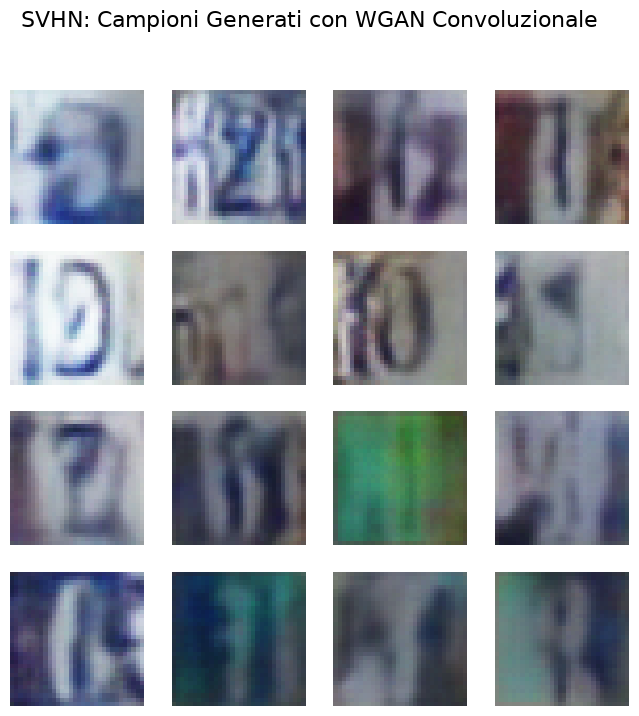

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------------------
# 1. CONFIGURAZIONE E IPERPARAMETRI
# -----------------------------------------------------------------------------------------
# Dispositivo: usa la GPU se disponibile per velocizzare il training delle reti convoluzionali.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Iperparametri del modello e del training
z_dim = 100           # Dimensione del vettore di rumore in ingresso
lr = 0.00005          # Learning rate basso per stabilità WGAN
batch_size = 64       # Dimensione del batch
n_critic = 5          # Numero di aggiornamenti del Critico per ogni aggiornamento del Generatore
clip_value = 0.01     # Valore di clipping per i pesi del Critico (vincolo di Lipschitz)
image_size = 32       # Dimensione immagini SVHN (32x32)
channels = 3          # Canali colore SVHN (RGB = 3)

# -----------------------------------------------------------------------------------------
# 2. PREPARAZIONE DEI DATI (SVHN)
# -----------------------------------------------------------------------------------------
# Definiamo le trasformazioni per il dataset SVHN.
# L'input deve essere ridimensionato a 32x32 (nativo SVHN) e normalizzato.
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalizzazione per 3 canali RGB
])

# Carichiamo il dataset SVHN (Street View House Numbers).
# Nota: SVHN usa 'split' invece di 'train' come argomento.
dataloader = DataLoader(
    datasets.SVHN(root='.', split='train', download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# -----------------------------------------------------------------------------------------
# 3. ARCHITETTURE CONVOLUZIONALI (DCGAN-like per WGAN)
# -----------------------------------------------------------------------------------------

class Generator(nn.Module):
    """
    Generatore Convoluzionale.
    Trasforma il vettore di rumore (z) in un'immagine RGB 32x32 tramite deconvoluzioni (ConvTranspose2d).
    """
    def __init__(self):
        super(Generator, self).__init__()
        # Input: N x z_dim x 1 x 1 (il vettore z viene rimodellato prima di entrare)
        self.model = nn.Sequential(
            # Layer 1: Da z_dim (100) a 256 canali, feature map 4x4
            # Kernel 4x4, Stride 1, Padding 0 -> Output: (N, 256, 4, 4)
            nn.ConvTranspose2d(z_dim, 256, kernel_size=4, stride=1, padding=0, bias=False),
            nn.ReLU(True),

            # Layer 2: Da 256 a 128 canali, espande a 8x8
            # Kernel 4x4, Stride 2, Padding 1 -> Output: (N, 128, 8, 8)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.ReLU(True),

            # Layer 3: Da 128 a 64 canali, espande a 16x16
            # Kernel 4x4, Stride 2, Padding 1 -> Output: (N, 64, 16, 16)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.ReLU(True),

            # Layer 4 (Output): Da 64 a 3 canali (RGB), espande a 32x32
            # Kernel 4x4, Stride 2, Padding 1 -> Output: (N, 3, 32, 32)
            nn.ConvTranspose2d(64, channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh() # Output finale tra -1 e 1
        )

    def forward(self, z):
        # Per usare ConvTranspose2d, z deve avere 4 dimensioni: (Batch, z_dim, 1, 1)
        z = z.view(z.size(0), z.size(1), 1, 1) # Reshape
        return self.model(z)

class Critic(nn.Module):
    """
    Critico Convoluzionale.
    Prende un'immagine 32x32 RGB e restituisce un punteggio reale (scalar score).
    Non usa Sigmoide finale (WGAN).
    """
    def __init__(self):
        super(Critic, self).__init__()
        # Input: (N, 3, 32, 32)
        self.model = nn.Sequential(
            # Layer 1: Da 3 canali a 64 canali. Downsampling a 16x16.
            # Kernel 4, Stride 2, Padding 1.
            nn.Conv2d(channels, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True), # LeakyReLU è standard nei discriminatori

            # Layer 2: Da 64 a 128 canali. Downsampling a 8x8.
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3: Da 128 a 256 canali. Downsampling a 4x4.
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 4 (Output): Collassa tutto in un singolo valore.
            # Input 4x4 -> Kernel 4x4 -> 1x1.
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False)
            # Uscita: (N, 1, 1, 1). Nessuna attivazione (Linear).
        )

    def forward(self, x):
        out = self.model(x)
        # Ritorna un tensore piatto (N, 1) o scalare, rimuovendo le dimensioni spaziali 1x1
        return out.view(-1)

# -----------------------------------------------------------------------------------------
# 4. INIZIALIZZAZIONE
# -----------------------------------------------------------------------------------------
gen = Generator().to(device)
critic = Critic().to(device)

# Inizializzazione dei pesi (Best practice per DCGAN/WGAN)
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

gen.apply(weights_init)
critic.apply(weights_init)

# Ottimizzatori RMSprop (Standard per WGAN con weight clipping)
opt_G = optim.RMSprop(gen.parameters(), lr=lr)
opt_C = optim.RMSprop(critic.parameters(), lr=lr)

# -----------------------------------------------------------------------------------------
# 5. TRAINING LOOP ASIMMETRICO
# -----------------------------------------------------------------------------------------
print("Inizio addestramento WGAN su SVHN...")

epochs = 20 

for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        curr_batch_size = real_imgs.size(0)

        # === STEP 1: TRAINING DEL CRITICO ===
        # Addestriamo il critico più volte
        loss_C_val = 0
        for _ in range(n_critic):
            opt_C.zero_grad()
            
            # Generazione fake
            z = torch.randn(curr_batch_size, z_dim, device=device)
            fake_imgs = gen(z).detach() # Detach per non propagare gradienti al Gen
            
            # Loss WGAN: -(E[D(real)] - E[D(fake)])
            # Il critico deve dare punteggi alti ai veri e bassi ai falsi
            loss_C = -(torch.mean(critic(real_imgs)) - torch.mean(critic(fake_imgs)))
            
            loss_C.backward()
            opt_C.step()

            # Weight Clipping
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)
            
            loss_C_val = loss_C.item()

        # === STEP 2: TRAINING DEL GENERATORE ===
        opt_G.zero_grad()
        
        # Generazione fake (questa volta tracciamo i gradienti)
        z = torch.randn(curr_batch_size, z_dim, device=device)
        gen_fake = gen(z)
        
        # Loss Generatore: -E[D(fake)]
        # Il generatore vuole che il critico dia punteggi alti (realistici) ai fake
        loss_G = -torch.mean(critic(gen_fake))
        
        loss_G.backward()
        opt_G.step()

        # Log ogni 100 batch
        if i % 100 == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch {i}/{len(dataloader)} \tW-Dist: {-loss_C_val:.4f}")

    print(f"Epoca {epoch} completata. Distanza Wasserstein finale: {-loss_C_val:.4f}")

# -----------------------------------------------------------------------------------------
# 6. VISUALIZZAZIONE RISULTATI
# -----------------------------------------------------------------------------------------
print("\nGenerazione campioni finali...")
gen.eval()

with torch.no_grad():
    # Input rumore
    noise = torch.randn(16, z_dim, device=device)
    # Generazione
    fake_samples = gen(noise).cpu()
    
    # Visualizzazione Griglia 4x4
    plt.figure(figsize=(8, 8))
    for i in range(16):
        plt.subplot(4, 4, i+1)
        # Denormalizzazione: [-1, 1] -> [0, 1]
        img = fake_samples[i].permute(1, 2, 0) # Da (C, H, W) a (H, W, C) per matplotlib
        img = img * 0.5 + 0.5
        plt.imshow(img.numpy()) # .numpy() non strettamente necessario con tensori recenti ma sicuro
        plt.axis('off')
    
    plt.suptitle("SVHN: Campioni Generati con WGAN Convoluzionale", fontsize=16)
    plt.show()